Ethiopia Food Prices — 05 TIME-SERIES ANALYSIS

Performs statistical profiling, decomposition, stationarity testing, and autocorrelation analysis on representative market-commodity series to prepare the ground for ARIMA/SARIMA modelling.

In [9]:
import warnings

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 20)

# Load the cleaned dataset
df = pd.read_csv('../data/eth_food_prices_clean.csv', parse_dates=['date'])
print(f'{len(df):,} rows x {df.shape[1]} columns loaded.')

62,875 rows x 21 columns loaded.


In [25]:
# 1. Select a representative market and commodity series
# Focus on 'Maize (white)' in 'Addis Ababa' 

market_focus = 'Addis Ababa'
commodity_focus = 'Maize (white)'


series_df = df[
    (df['market'] == market_focus)
    & (df['commodity'] == commodity_focus)
    & (df['pricetype'] == 'Wholesale')

].copy()

series_df = series_df.sort_values('date').set_index('date')

# Resample to strict Monthly Start frequency for a continuous chronological sequence
y = series_df['usdprice'].resample('MS').mean()

print(f'Selected Series: {commodity_focus} ({unit_focus}) in {market_focus}')
print(f'Total observations: {len(y)}')
print(f'Inferred Frequency: {y.index.inferred_freq}')

Selected Series: Maize (white) (100 KG) in Addis Ababa
Total observations: 262
Inferred Frequency: MS


In [26]:
# 2. Check and handle missing periods
missing_count = y.isna().sum()
print(f'Missing periods before interpolation: {missing_count}')

# Linear interpolation for minor gaps so chronological analysis doesn't break
y = y.interpolate(method='linear')
print(f'Missing periods after interpolation: {y.isna().sum()}')

Missing periods before interpolation: 4
Missing periods after interpolation: 0


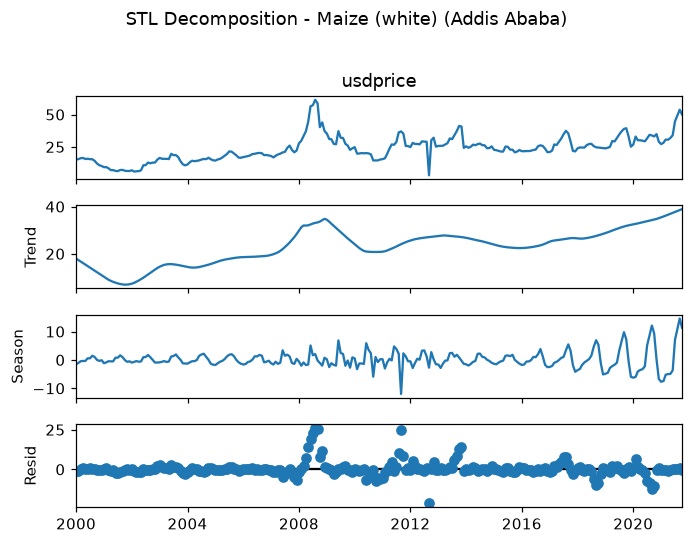

In [27]:
# 3. STL Decomposition (Trend, Season, Residual)
# period=12 assumes a standard 12-month annual agricultural/price cycle
stl = STL(y, period=12, robust=True)
result = stl.fit()

fig = result.plot()
plt.suptitle(f'STL Decomposition - {commodity_focus} ({market_focus})', y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# 4. Stationarity Tests (ADF and KPSS functions)
def check_stationarity(timeseries, name='Series'):
  print(f' Stationarity Test: {name}')
  clean_ts = timeseries.dropna()

  if len(clean_ts) < 15:
    print(
        f'Skipping test: Sample size ({len(clean_ts)}) is too short for ADF/KPSS.'
    )
    print()
    return

  # ADF Test with explicit regression='c' (constant)
  try:
    dftest = adfuller(clean_ts, regression='c', autolag='AIC')
    print(
        f'ADF p-value: {dftest[1]:.4f} -> '
        f"{'Stationary' if dftest[1] <= 0.05 else 'Non-stationary'}"
    )
  except Exception as e:
    print(f'ADF Test failed: {e}')

  # KPSS Test
  with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    try:
      kpsstest = kpss(clean_ts, regression='c', nlags='auto')
      print(
          f'KPSS p-value: {kpsstest[1]:.4f} -> '
          f"{'Stationary' if kpsstest[1] > 0.05 else 'Non-stationary'}"
      )
    except Exception as e:
      print(f'KPSS Test failed: {e}')
  print()


check_stationarity(y, 'Original USD Price Series')

 Stationarity Test: Original USD Price Series
ADF p-value: 0.0816 -> Non-stationary
KPSS p-value: 0.0100 -> Non-stationary



Time-series models like ARIMA require
stationarity (a flat, stable mean and constant
variance over time). When a series fails both ADF
and KPSS tests, it means we must apply differencing 
to stabilize the mean before modeling.

In [30]:
# 5. Differencing to achieve stationarity 
# First differencing removes the long-term trend, establishing stationarity (d=1)
y_diff = y.diff().dropna()
check_stationarity(y_diff, 'First-Differenced Series (d=1)')

 Stationarity Test: First-Differenced Series (d=1)
ADF p-value: 0.0000 -> Stationary
KPSS p-value: 0.1000 -> Stationary



First differencing subtracts each month's price
 from the previous month's price. Instead of 
 looking at raw inflated prices, the model now
  looks at monthly price changes (increases or decreases),
   which bounce neatly around a flat, stable horizontal line.

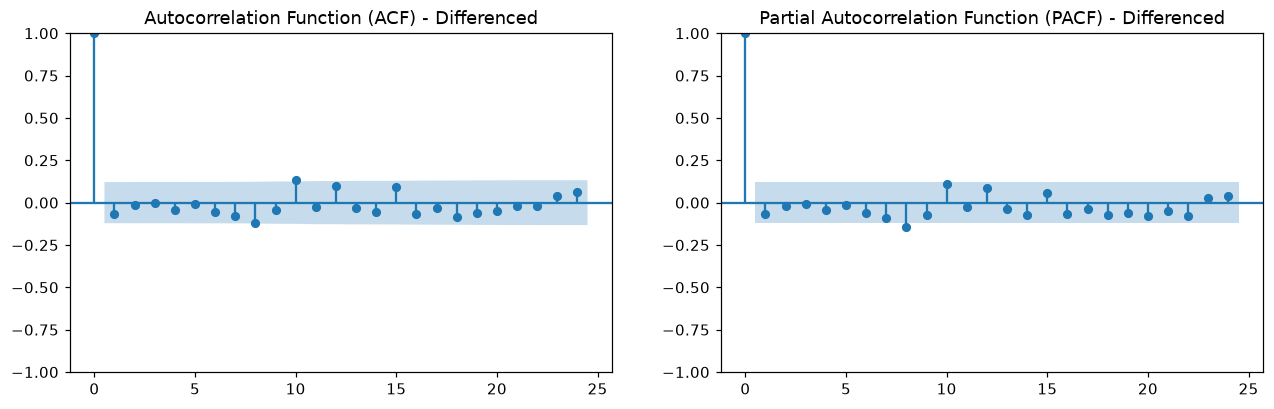

In [31]:
# 7. ACF and PACF Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff, ax=axes[0], lags=24)
axes[0].set_title('Autocorrelation Function (ACF) - Differenced')
plot_pacf(y_diff, ax=axes[1], lags=24, method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF) - Differenced')
plt.show()

By combining our tests, we now have our blueprint
 parameters for building an ARIMA($p, d, q$) model:
      d = 1: We needed 1 round of differencing to make the series stationary.

      p and q: The significant spikes poking out of
      the blue bands in the PACF and ACF charts give 
      us our starting candidate numbers for p and q 
      in the upcoming model notebook!